# ROGUE Purity Audit — Reference Cell Type Annotations

**Audit reference cell types** — compute ROGUE for each `global.cluster4` group. These are the GSEA gene sets; if any is impure, the GSEA NES scores conflate sub-states.

This notebook audits the original cell-type annotations with ROGUE on the **full transcriptome**. It is the canonical absolute-scale purity reference for the 17 reference labels — it's what gets compared against the 0.9 threshold from Liu et al. (2020) and what should be reported as "the annotation purity" in the paper.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

## 1. Configuration

Match these to your existing GSEA notebook + point at the raw-count AnnData.

In [2]:
# --- raw-count AnnData (same one used as cNMF input) ---
ADATA_PATH = "data/hnc_myeloid_2021.h5ad"
COUNTS_LAYER = None  # set to a layer name if counts aren't in .X; else .X is used

# --- metadata ---
METADATA_PATH = "data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL   = None
CELLTYPE_COL  = "global.cluster4"
METADATA_SEP  = ","

# --- ROGUE params ---
ROGUE_PLATFORM = "UMI"   # 'UMI' (=droplet) or 'full-length'
ROGUE_SPECIES  = "Human" # 'Human' or 'Mouse'
ROGUE_K        = 45      # 45 for UMI, 500 for full-length; reference factor (NOT cNMF K)
MIN_CELLS_PER_GROUP = 15

OUT_DIR = "rogue_purity_results_celltype"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# Get raw counts as a dense genes × cells matrix (ROGUE expects this orientation)
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

# Sanity check: ROGUE assumes raw counts (integer-valued, non-negative)
if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

# Metadata
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
print(f"Aligned to {len(common)} cells")

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells


## 3. ROGUE wrapper

Calls the R `rogue()` function on a counts matrix + per-cell labels and returns a tidy DataFrame. ROGUE returns a samples × clusters matrix (NaN where a cluster isn't present in a sample); we collapse by taking the mean across samples for a single per-cluster value.

In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, species=ROGUE_SPECIES,
                  k=ROGUE_K, min_cells=MIN_CELLS_PER_GROUP,
                  verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    # --- Filter tiny groups ---
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    # --- Build (sample, cluster) work list ---
    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        for _, r in pairs.iterrows():
            print(f"  {r['sample']} / {r['cluster']}: {r['n_cells']} cells")
        print()

    # --- Push the full counts matrix to R once ---
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r('''
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    ''')

    # --- Per-(sample, cluster) loop in Python ---
    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f'''
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            ''')
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

## 4. Audit the reference cell type annotations

These labels are the "gene sets" in your GSEA. Any cluster with ROGUE < ~0.9 is heterogeneous; GEPs that GSEA assigns to it may be capturing a sub-state, not the full label.

In [5]:
# Optionally split by sample/patient if you have a column for it
# samples = meta['patient_id']  # uncomment if available
samples = meta['orig.ident']

ct_csv = f"{OUT_DIR}/rogue_celltype_audit.csv"
if os.path.exists(ct_csv):
    print(f"Found existing {ct_csv} — loading instead of recomputing.")
    ct_long = pd.read_csv(ct_csv)
else:
    ct_long, ct_wide = compute_rogue(
        counts_df,
        labels=meta[CELLTYPE_COL],
        samples=samples,
    )
    ct_long.to_csv(ct_csv, index=False)

# Summarize: median ROGUE per cluster (across samples, if any)
ct_summary = (ct_long.groupby('cluster')
                     .agg(median_ROGUE=('ROGUE', 'median'),
                          mean_ROGUE  =('ROGUE', 'mean'),
                          n_samples   =('ROGUE', 'count'),
                          total_cells =('n_cells', 'sum'))
                     .sort_values('median_ROGUE'))
ct_summary

Counts: 23,630 genes × 26,444 cells
Computing ROGUE for 312 (sample, cluster) pair(s)
  GSM4138134 / Mono_CD14: 874 cells
  GSM4138116 / Mono_CD14_THBS1: 668 cells
  GSM4138126 / Mono_CD14: 618 cells
  GSM4138156 / Mono_CD14: 584 cells
  GSM4138140 / Mono_CD14: 468 cells
  GSM4138120 / Mono_CD14_ID1: 464 cells
  GSM4138132 / Mono_CD14: 443 cells
  GSM4138123 / Mac_CXCL9: 423 cells
  GSM4138137 / Mac_IL1Bint: 398 cells
  GSM4138142 / Mono_CD14: 360 cells
  GSM4138138 / Mono_CD14: 339 cells
  GSM4138136 / Mono_CD14: 329 cells
  GSM4138125 / Mac_SPP1: 319 cells
  GSM4138163 / Mono_CD14_IL1B: 313 cells
  GSM4138130 / Mono_CD14: 306 cells
  GSM4138160 / Mono_CD14_THBS1: 302 cells
  GSM4138135 / Mac_IL1Bint: 300 cells
  GSM4138162 / Mono_CD14_IL1B: 292 cells
  GSM4138165 / Mono_CD14: 285 cells
  GSM4138110 / Mono_CD14_THBS1: 255 cells
  GSM4138131 / Mono_TIL: 254 cells
  GSM4138128 / Mono_CD14: 234 cells
  GSM4138122 / Mono_CD14: 234 cells
  GSM4138167 / Mono_CD14: 234 cells
  GSM4138166 / M

ROGUE:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ GSM4138134 / Mono_CD14                 ROGUE=0.949  (n= 874,  2.8s)
  ✓ GSM4138116 / Mono_CD14_THBS1           ROGUE=0.894  (n= 668,  0.2s)
  ✓ GSM4138126 / Mono_CD14                 ROGUE=0.915  (n= 618,  0.2s)
  ✓ GSM4138156 / Mono_CD14                 ROGUE=0.892  (n= 584,  0.2s)
  ✓ GSM4138140 / Mono_CD14                 ROGUE=0.951  (n= 468,  0.1s)
  ✓ GSM4138120 / Mono_CD14_ID1             ROGUE=0.846  (n= 464,  0.2s)
  ✓ GSM4138132 / Mono_CD14                 ROGUE=0.953  (n= 443,  0.1s)
  ✓ GSM4138123 / Mac_CXCL9                 ROGUE=0.577  (n= 423,  0.3s)
  ✓ GSM4138137 / Mac_IL1Bint               ROGUE=0.625  (n= 398,  0.2s)
  ✓ GSM4138142 / Mono_CD14                 ROGUE=0.928  (n= 360,  0.1s)
  ✓ GSM4138138 / Mono_CD14                 ROGUE=0.949  (n= 339,  0.1s)
  ✓ GSM4138136 / Mono_CD14                 ROGUE=0.903  (n= 329,  0.1s)
  ✓ GSM4138125 / Mac_SPP1                  ROGUE=0.539  (n= 319,  0.2s)
  ✓ GSM4138163 / Mono_CD14_IL1B            ROGUE=0.930  (n= 313,

,median_ROGUE,mean_ROGUE,n_samples,total_cells
cluster,,,,
Mac_SPP1,0.625583,0.656306,7,532
cDC2_CD1C,0.640848,0.647154,21,886
Mac_IL1Bint,0.682749,0.685116,21,1792
Mac_CXCL9,0.720893,0.710826,13,1139
Mac_IL1B,0.748475,0.738859,10,722
mregDC_LAMP3,0.752654,0.766246,12,380
Mono_TIL,0.763075,0.766121,13,913
cDC1_CLEC9A,0.815049,0.809760,6,162
cDC2_CD33,0.870551,0.856640,36,1185


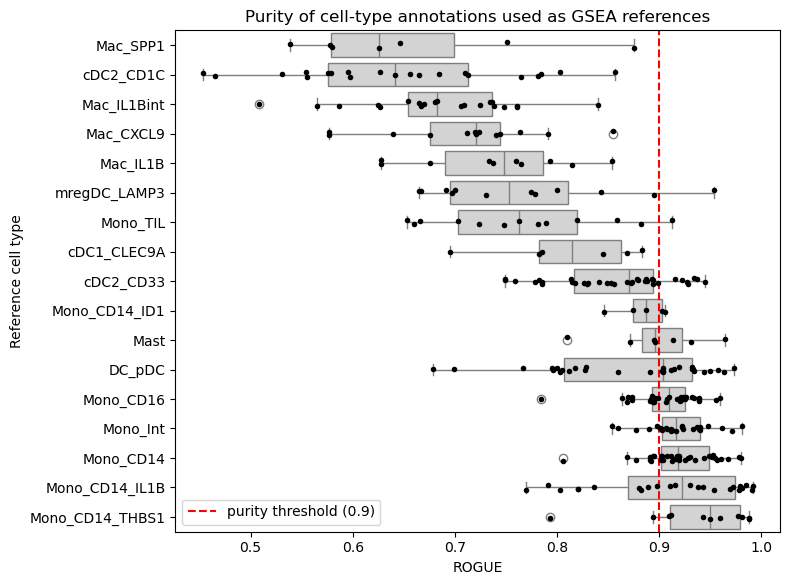

In [6]:
# Plot — flag clusters below 0.9
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(ct_summary))))
order = ct_summary.index
sns.boxplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='lightgray', ax=ax)
sns.stripplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='black', size=4, ax=ax)
ax.axvline(0.9, ls='--', color='red', label='purity threshold (0.9)')
ax.set_xlabel('ROGUE')
ax.set_ylabel('Reference cell type')
ax.set_title('Purity of cell-type annotations used as GSEA references')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rogue_celltype_audit.png", dpi=150)
plt.show()